In [1]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.12) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


# Utilities

In [130]:
def vonmises_pdf(x, mu, kappa):
    return np.exp(kappa * np.cos(x - mu)) / (2 * np.pi * i0(kappa))

def plot_forward_samples(prior_trace, valid_gabors, lambdas):
    orientation_samples = prior_trace["prior"]["orientation"].data.squeeze()
    neuron_samples = prior_trace["prior"]["neuron"].data.squeeze()
    stimulus_samples = prior_trace["prior_predictive"]["stimulus"].data.squeeze()
    fig, axs = plt.subplots(nrows=6, ncols=9, dpi=300, sharex="col")
    # set a figure level title but with smaller font
    fig.suptitle("Prior samples", fontsize=8)
    # name the first column of the figure as "stimulus" with small font size
    axs[0, 0].set_title("Stimulus", fontsize=6)
    # name rest of columns as "neuron" i
    for i in range(1, 6):
        axs[0, i].set_title(f"Neuron {i}", fontsize=6)
    # name the last column as "global orientation"
    axs[0, 6].set_title("Sample", fontsize=6)
    axs[0, 7].set_title("Mean rate", fontsize=6)
    axs[0, 8].set_title("Orientation", fontsize=6)
    # axs[0, 9].set_title("Correlation", fontsize=6)
    for i, ax in enumerate(axs[:, 0]):
        ax.imshow(stimulus_samples[i], cmap='gray', vmin=-1, vmax=1)
        ax.axis("off")
    for i, axs_features in enumerate(axs[:, 1:-3]):
        for j, ax in enumerate(axs_features):
            ax.imshow(valid_gabors[j] * neuron_samples[i][j], cmap='gray', vmin=-1, vmax=1)
            ax.axis("off")
    for i, ax in enumerate(axs[:, -3]):
        ax.bar(np.arange(1, 6), neuron_samples[i], color="limegreen")
        # make font size of tick labels very small
        ax.tick_params(axis="both", which="major", labelsize=3)
        # move y ticks a little bit to the right
        ax.yaxis.set_tick_params(pad=1.5)
        ax.xaxis.set_tick_params(pad=1.5)
    # plot bar plot of spike rates in the last column but one
    for i, ax in enumerate(axs[:, -2]):
        ax.bar(np.arange(1, 6), 1/lambdas[i], color="darkgreen")
        ax.tick_params(axis="both", which="major", labelsize=3)
        ax.yaxis.set_tick_params(pad=1.5)
        ax.xaxis.set_tick_params(pad=1.5)
    for i, ax in enumerate(axs[:, -1]):
        # print the orientation value on the top left corner of the plot
        # print the degree symbol with the latex command
        ax.text(0.02, 0.90, f"{int(np.rad2deg(orientation_samples[i]))}$\degree$", transform=ax.transAxes, fontsize=3)
        # convert orientation to angle and draw line passing through the origin with that angle
        # ax.plot([0, np.cos(orientation_samples[i])], [0, np.sin(orientation_samples[i])], color="red")
        # convert orientation to a vector and plot it
        # ax.quiver(0, 0, np.cos(orientation_samples[i]), np.sin(orientation_samples[i]), color="red")
        # convert orientation to a long vector and plot it
        ax.quiver(0, 0, np.cos(orientation_samples[i]), np.sin(orientation_samples[i]), scale=2, width=0.05, color="orange")
        # convert orientation to a long vector and scale it and plot it

        ax.set_xticks([])
        ax.set_yticks([])
    # plot the last column as correlation matrix of neuron samples
    # for i, ax in enumerate(axs[:, -1]):
    #     # plot only lower triangle of correlation matrix
    #     sns.heatmap(np.corrcoef(prior_trace["neuron"].T), ax=ax, cmap="seismic")
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     ax.set_aspect("equal")
    #     # remove the colorbar
    #     ax.collections[0].colorbar.remove()

def sample_prior(vonmises_loc, vonmises_kappa, n_samples, valid_gabors, valid_orientations):
    n_neurons = len(valid_gabors)
    stimulus_sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        o = pm.Uniform("orientation", lower=0, upper=np.pi)
        z = pm.Exponential(
            "neuron", 
            lam=vonmises_pdf(o - valid_orientations, vonmises_loc, vonmises_kappa),
            shape=n_neurons
        )
        x = pm.Normal("stimulus", mu=valid_gabors.transpose(1, 2, 0) @ z, sigma=stimulus_sigma, observed=valid_gabors[0])
        prior_trace = pm.sample_prior_predictive(n_samples, random_seed=seed)
    return prior_trace

In [3]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [15],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : gabor_locations,
    "orientations"        : [0., np.pi/2],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)

In [4]:
total_param_count = np.prod(gabor_set.num_params())
param_combos = [gabor_set.params_dict_from_idx(idx) for idx in range(total_param_count)]
valid_params_gabors = [(param_combos[idx], gabor_set.stimulus_from_idx(idx)) for idx in range(total_param_count) if not (param_combos[idx]["orientation"] == 0. and param_combos[idx]["location"] == (25, 25))]
valid_params_gabors = sorted(valid_params_gabors, key=lambda x: x[0]["orientation"])
valid_gabors = np.array([gabor for _, gabor in valid_params_gabors])
valid_orientations = np.array([param["orientation"] for param, _ in valid_params_gabors])

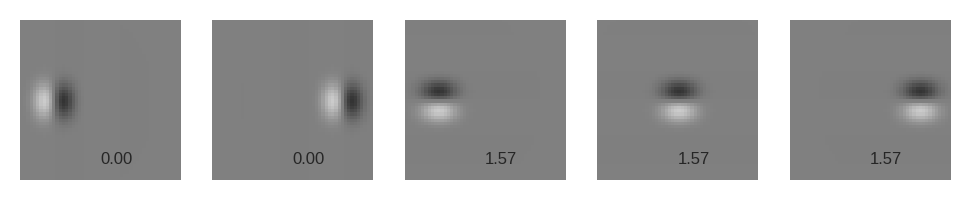

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=5, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = valid_gabors[idx]
    orientation = valid_orientations[idx]
    ax.imshow(gabor, cmap='gray', vmin=-1, vmax=1)
    # print orientation in small font in the top of each axis
    ax.text(0.5, 0.1, f"{orientation:.2f}", transform=ax.transAxes, fontsize=6)
    ax.axis("off")


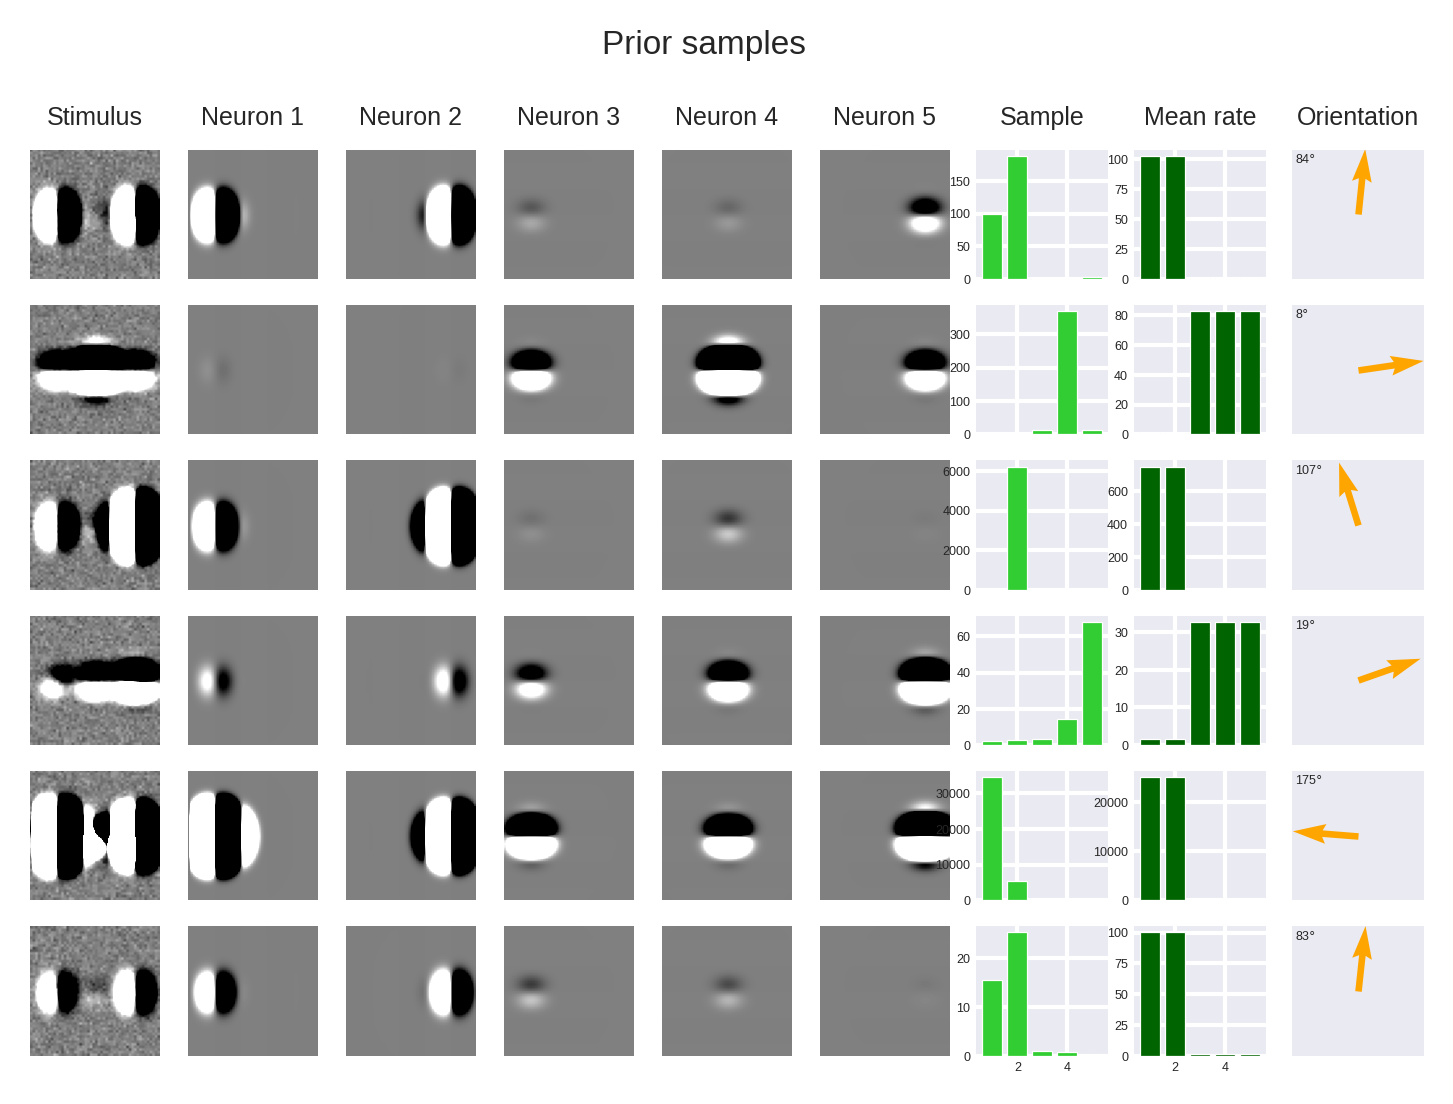

In [133]:
vonmises_loc = 0
vonmises_kappa = 5
n_samples = 6
prior_trace = sample_prior(vonmises_loc, vonmises_kappa, n_samples, valid_gabors, valid_orientations)
lambdas = np.array([vonmises_pdf(orientation - valid_orientations, vonmises_loc, vonmises_kappa) for orientation in prior_trace['prior']["orientation"].data.flatten()])
plot_forward_samples(prior_trace, valid_gabors, lambdas)

Text(0.5, 1.0, 'Prior correlation matrix of neuron samples')

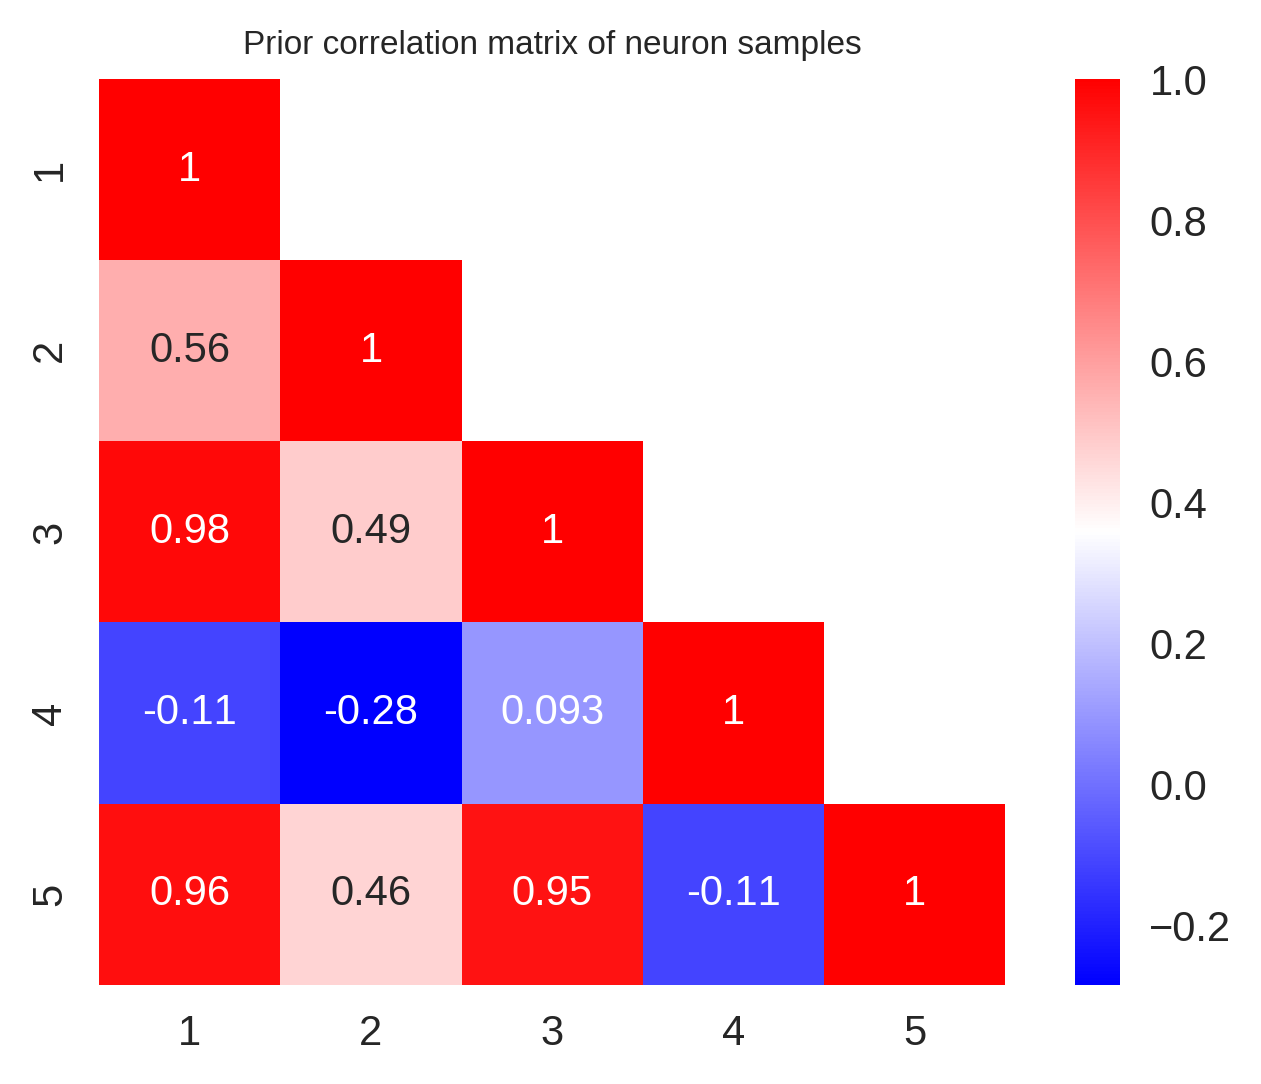

In [134]:
corr = np.corrcoef(prior_trace["prior"]["neuron"].data.squeeze().T)
fig, ax = plt.subplots(dpi=300)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, cmap="bwr", ax=ax)
ax.set_facecolor("white")
ax.set_aspect("equal")
ax.set_xticklabels(range(1, 6))
ax.set_yticklabels(range(1, 6))
ax.set_title("Prior correlation matrix of neuron samples", fontsize=8)

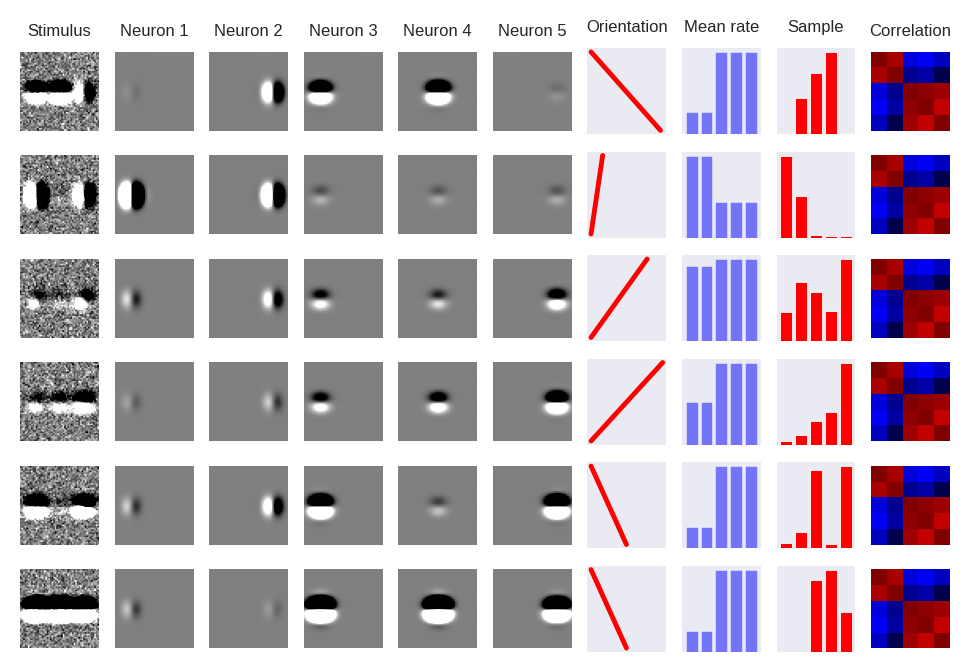

In [13]:
vonmises_loc = 0
vonmises_kappa = 1
n_samples = 6
prior_trace = sample_prior(vonmises_loc, vonmises_kappa, n_samples, valid_gabors, valid_orientations)
lambdas = np.array([vonmises_pdf(orientation - valid_orientations, vonmises_loc, vonmises_kappa) for orientation in prior_trace["orientation"]])
plot_forward_samples(prior_trace, valid_gabors, lambdas)

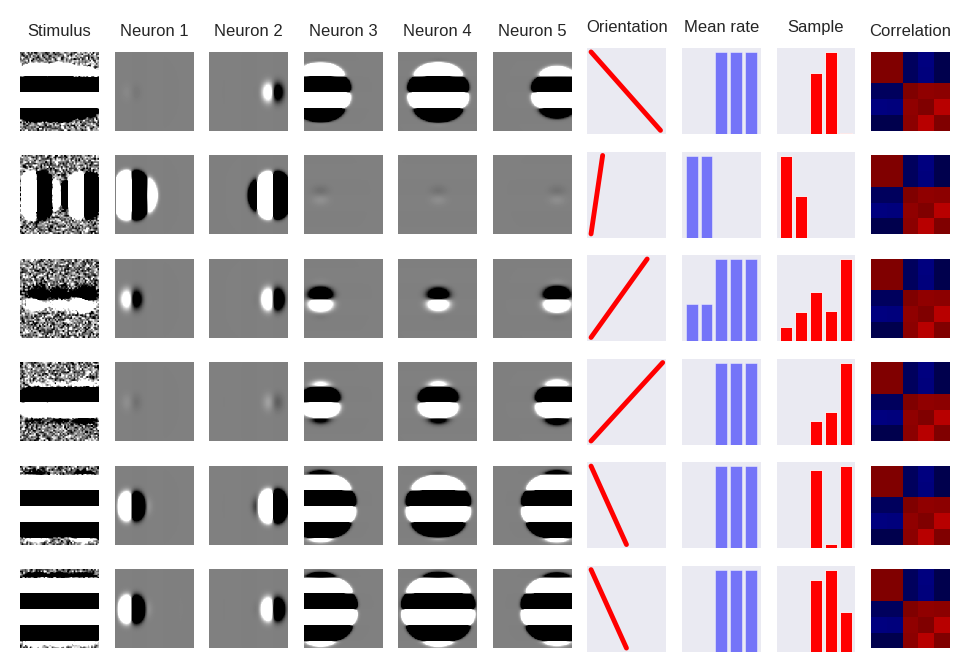

In [26]:
vonmises_loc = 0
vonmises_kappa = 10
n_samples = 6
prior_trace = sample_prior(vonmises_loc, vonmises_kappa, n_samples, valid_gabors, valid_orientations)
lambdas = np.array([vonmises_pdf(orientation - valid_orientations, vonmises_loc, vonmises_kappa) for orientation in prior_trace["orientation"]])
plot_forward_samples(prior_trace, valid_gabors, lambdas)

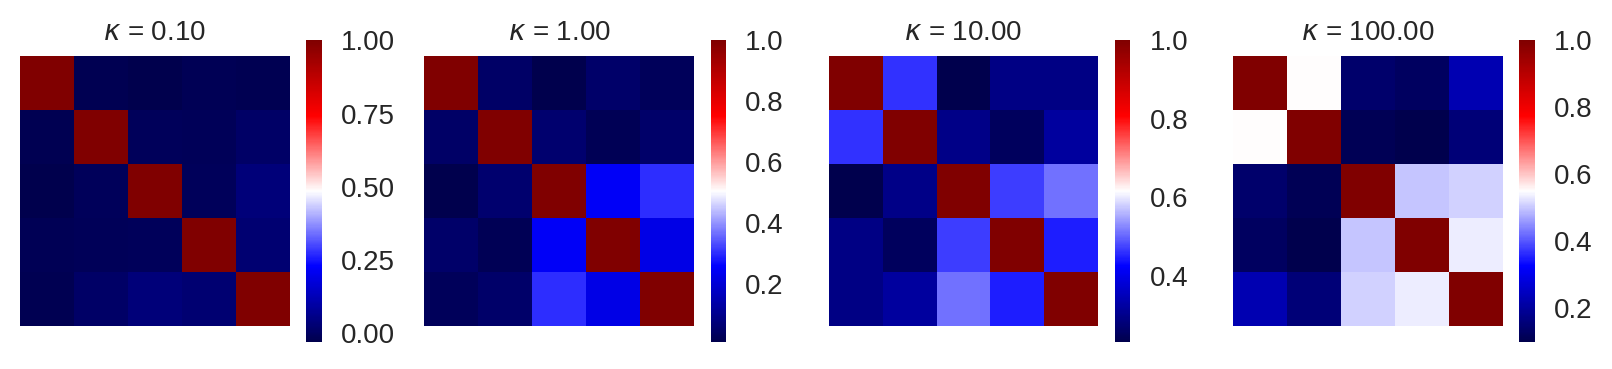

In [25]:
kappas = [0.1, 1, 10, 100]
n_samples_per_kappa = 1000
fig, axs = plt.subplots(nrows=1, ncols=len(kappas), dpi=200, figsize=(10, 2))
for idx, ax in enumerate(axs.ravel()):
    prior_trace_per_kappa = sample_prior(vonmises_loc, kappas[idx], n_samples_per_kappa, valid_gabors, valid_orientations)
    sns.heatmap(np.corrcoef(prior_trace_per_kappa["neuron"].T), ax=ax, cmap="seismic")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    # make kappa value as title but in small font
    ax.set_title(f"$\kappa$ = {kappas[idx]:.2f}", fontsize=10)